In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
#import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA
import mdtraj

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)

rhresids = arange(292,496)
huresids = systems[1][0].residues.resids
    
protein=[]
proteinstrings=[]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein"))
        sub2.append("protein")
        
    protein.append(sub)
    proteinstrings.append(sub2)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
contacts_2d=0
for i in range(5):
    contacts_2d+=load("../complex/complexContacts_2d_trajectory"+str(i+1)+".npy")/5

(0.0, 205.0)

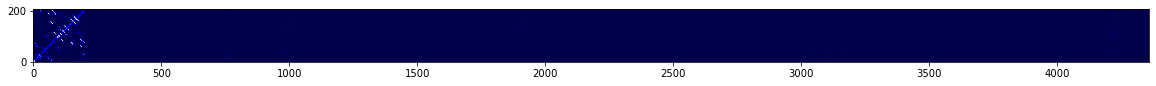

In [4]:
figure(figsize = (20,100))
imshow(contacts_2d,origin = "lower",cmap = "seismic")
ylim(0,205)

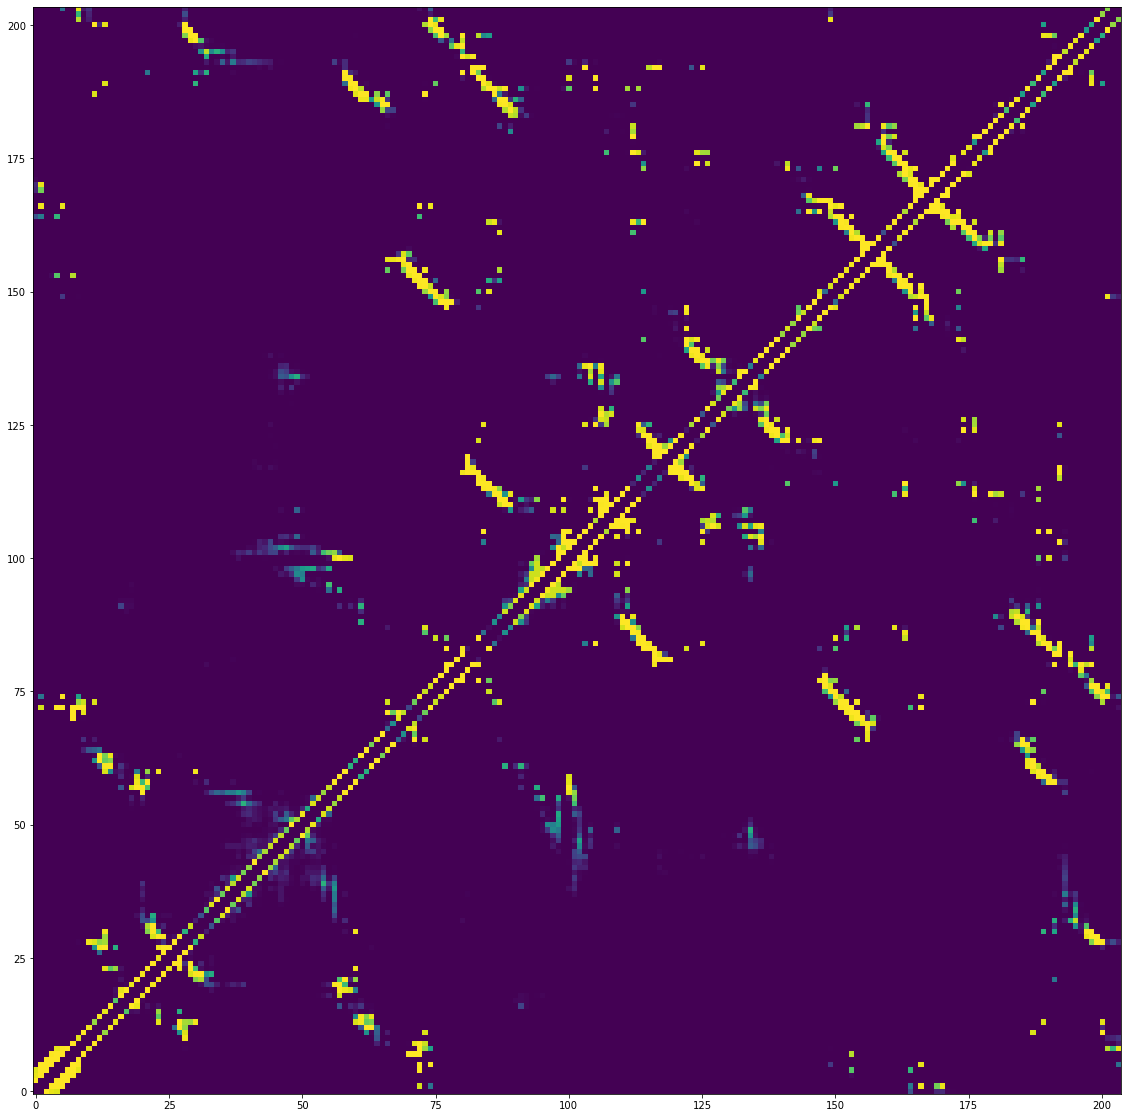

In [5]:
figure(figsize = (20,20))
imshow(contacts_2d[:493-290+1,:493-290+1],origin = "lower")

Text(0, 0.5, 'SPRY Residue')

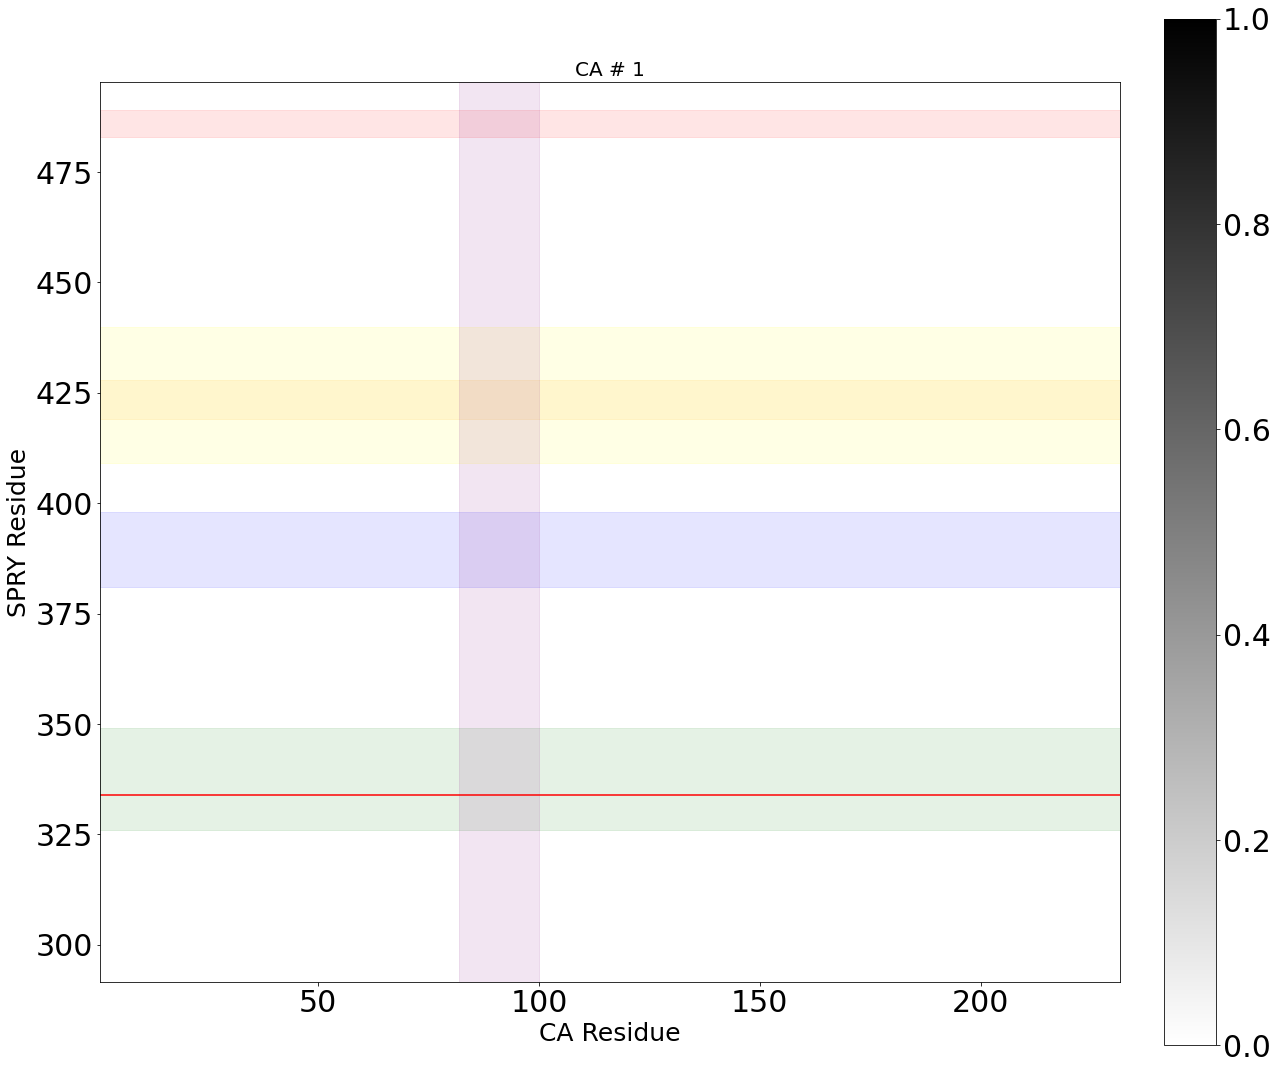

In [6]:
i=1
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)

axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
cbar=colorbar(fraction=0.046, pad=0.04)
cbar.ax.tick_params(labelsize=30) 
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

Text(0, 0.5, 'SPRY Residue')

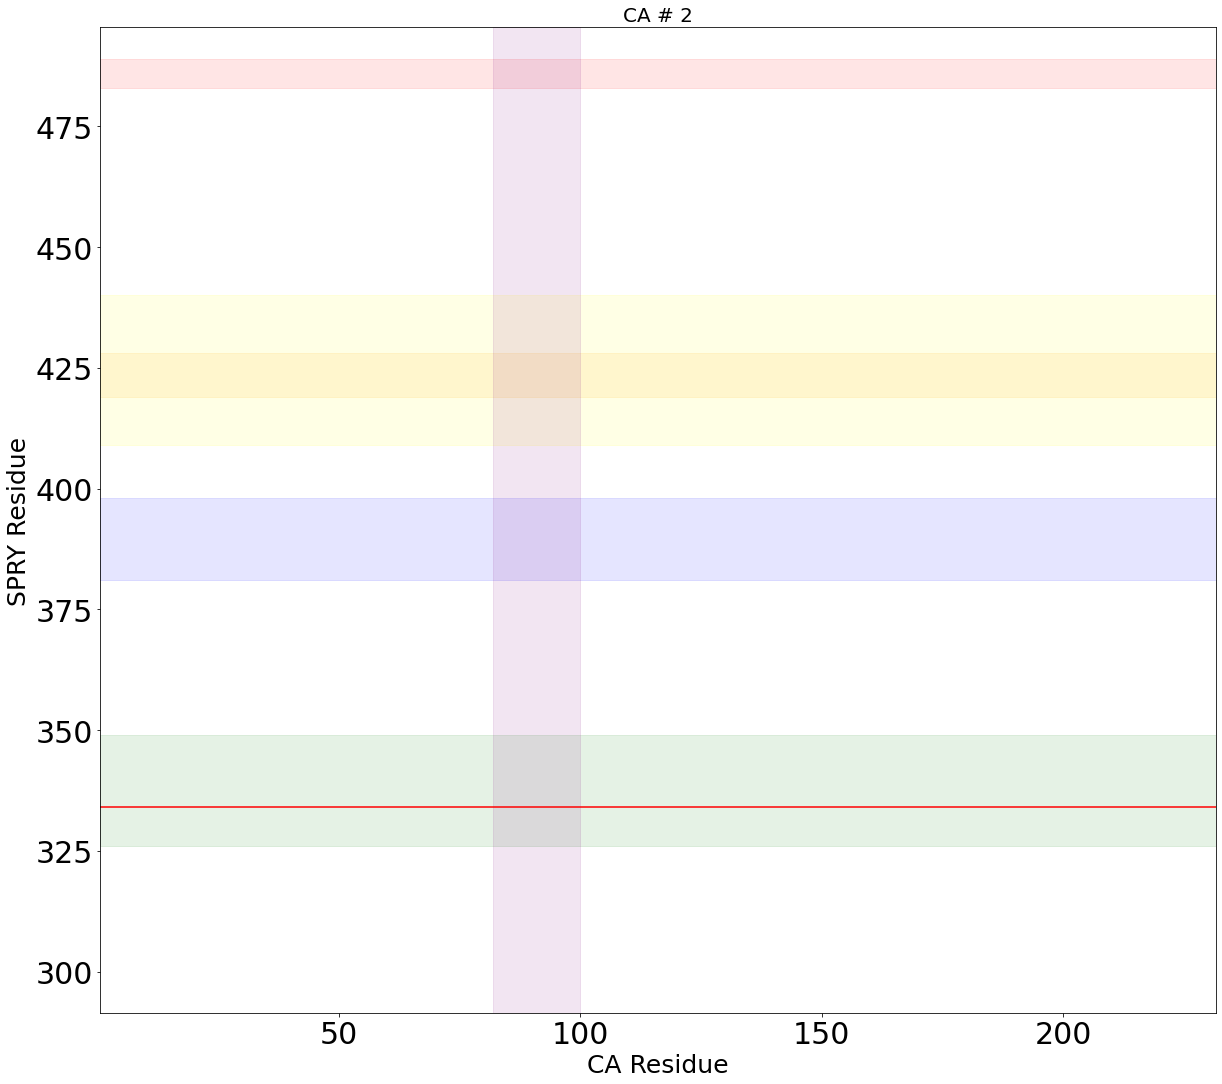

In [7]:
i=2
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)
#colorbar()
xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")


axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

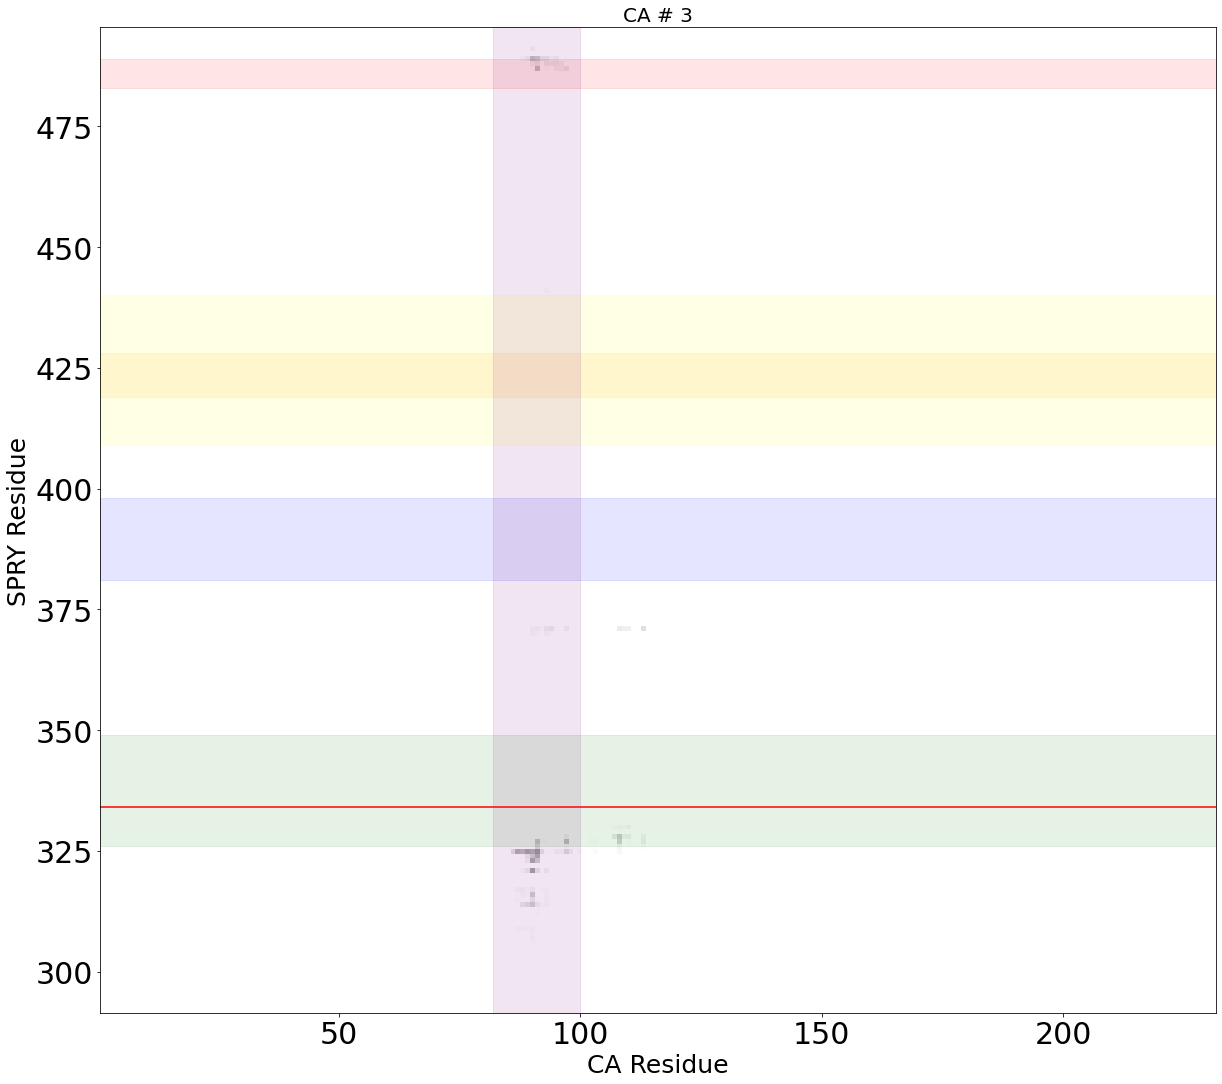

In [8]:
i=3
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)
axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1)
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")


axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

save("CA3_contacts.npy",contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))])

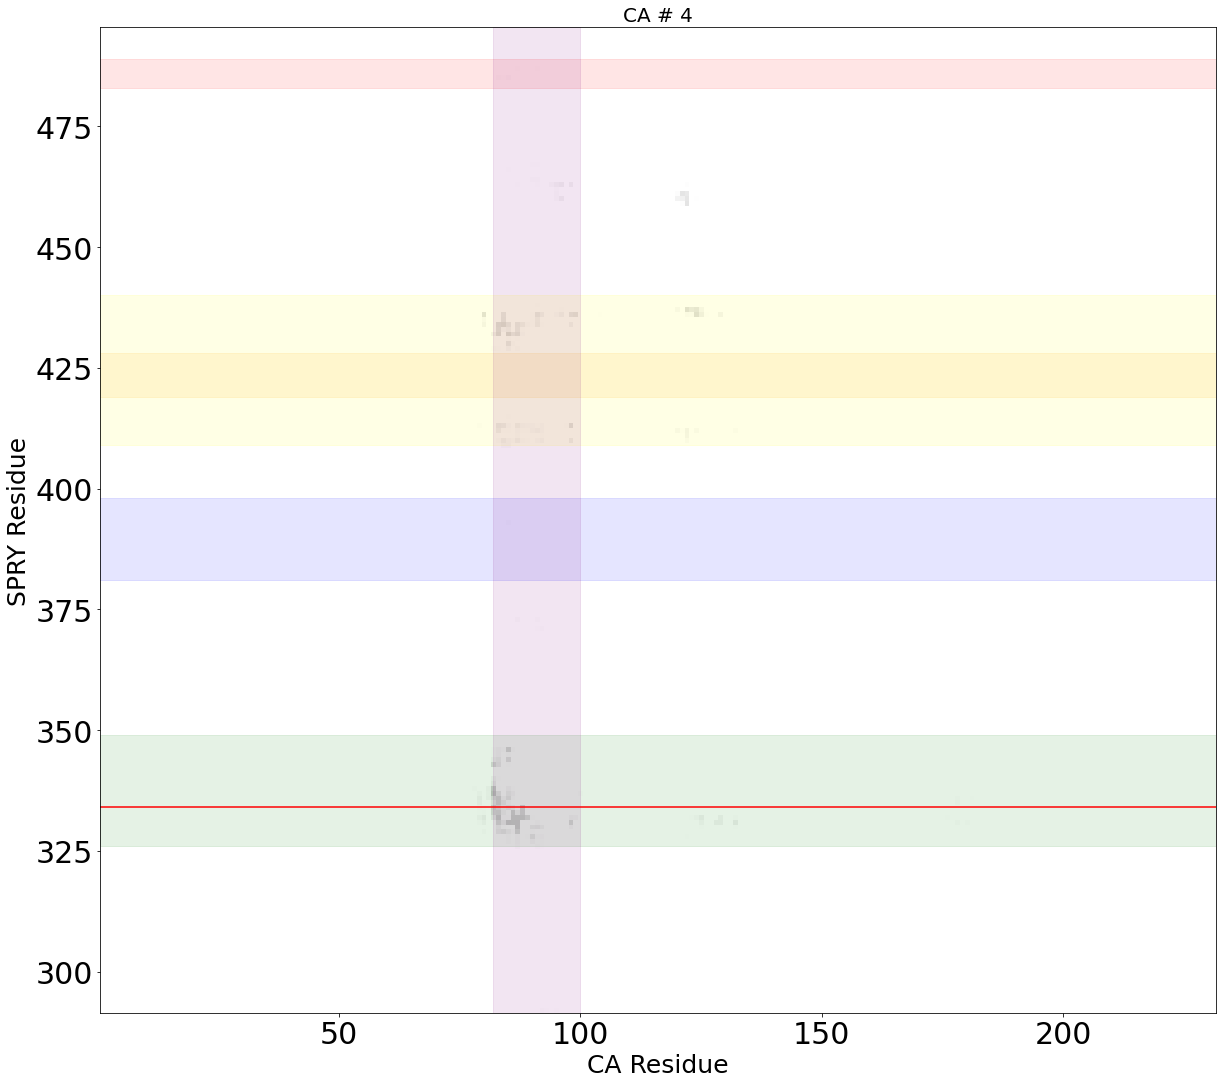

In [9]:
i=4
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)
axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")


axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

save("CA4_contacts.npy",contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))])

Text(0, 0.5, 'SPRY Residue')

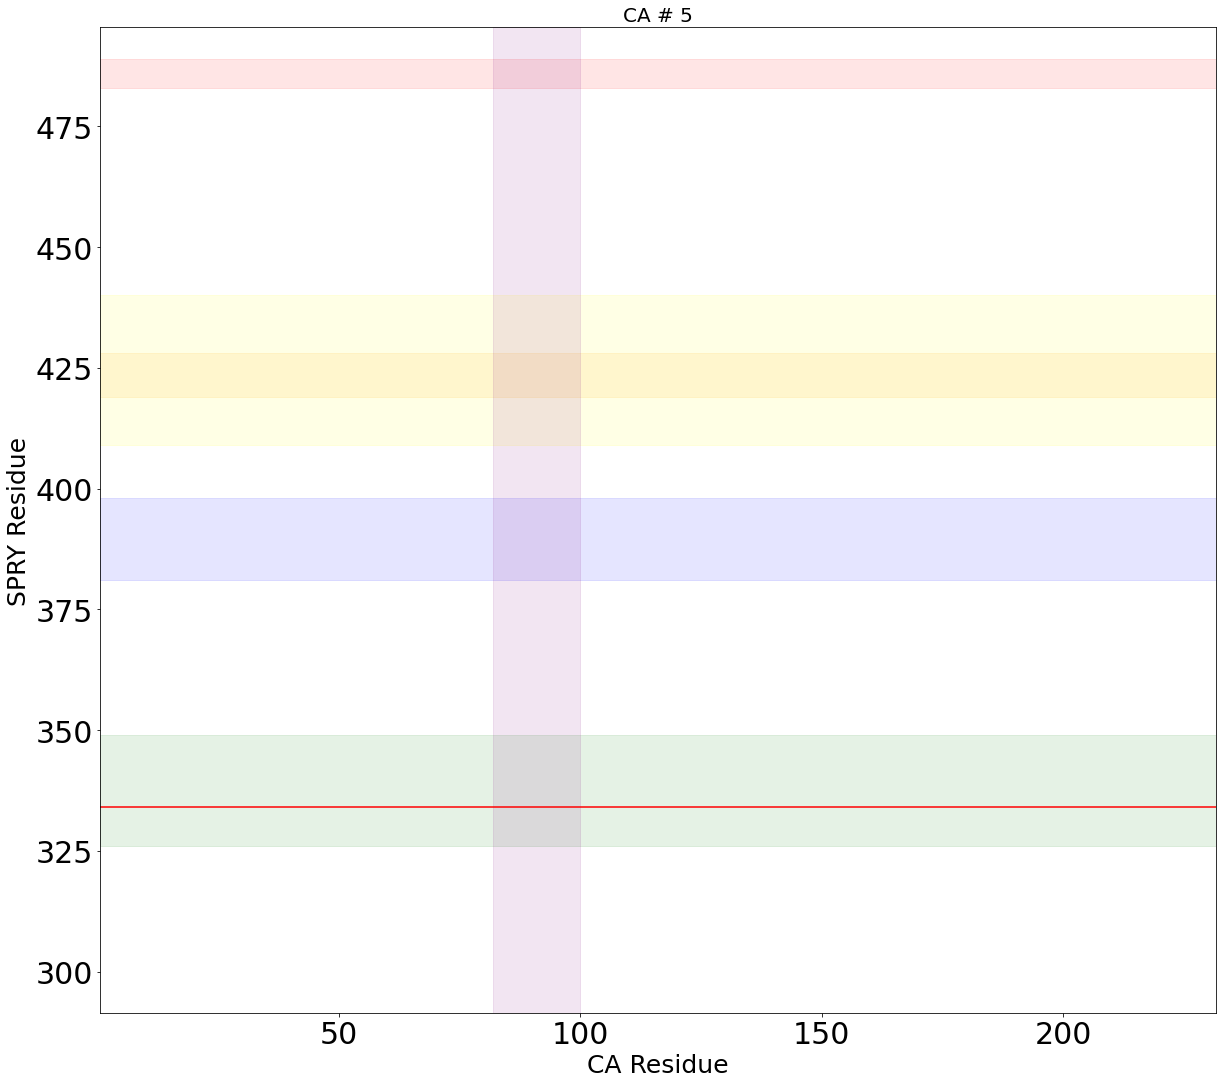

In [10]:
i=5
nspry = 494-290
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")


axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

Text(0, 0.5, 'SPRY Residue')

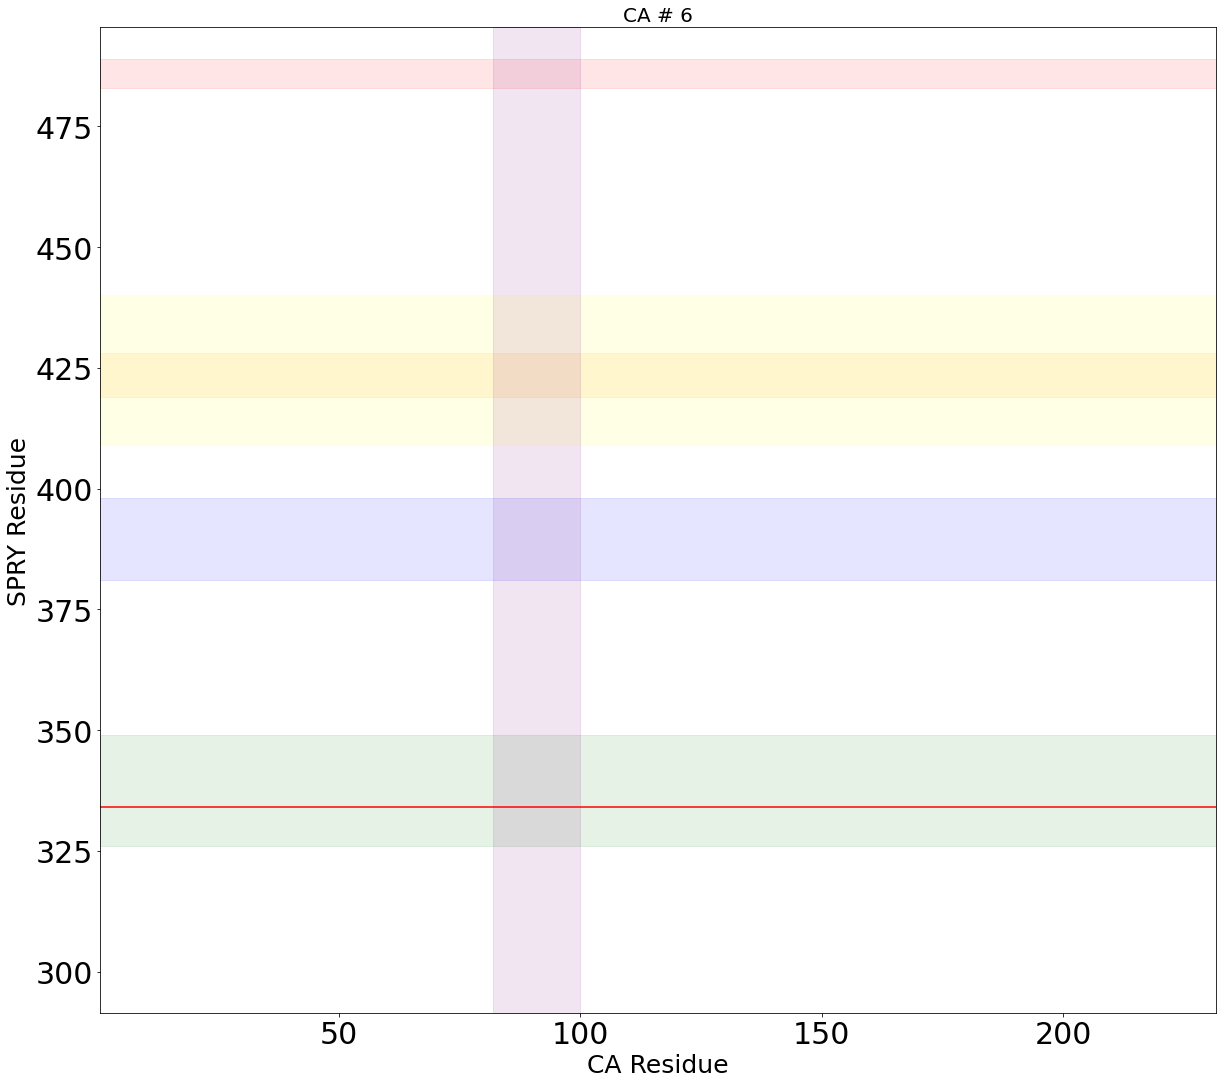

In [11]:
i=6
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")


axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

Text(0, 0.5, 'SPRY Residue')

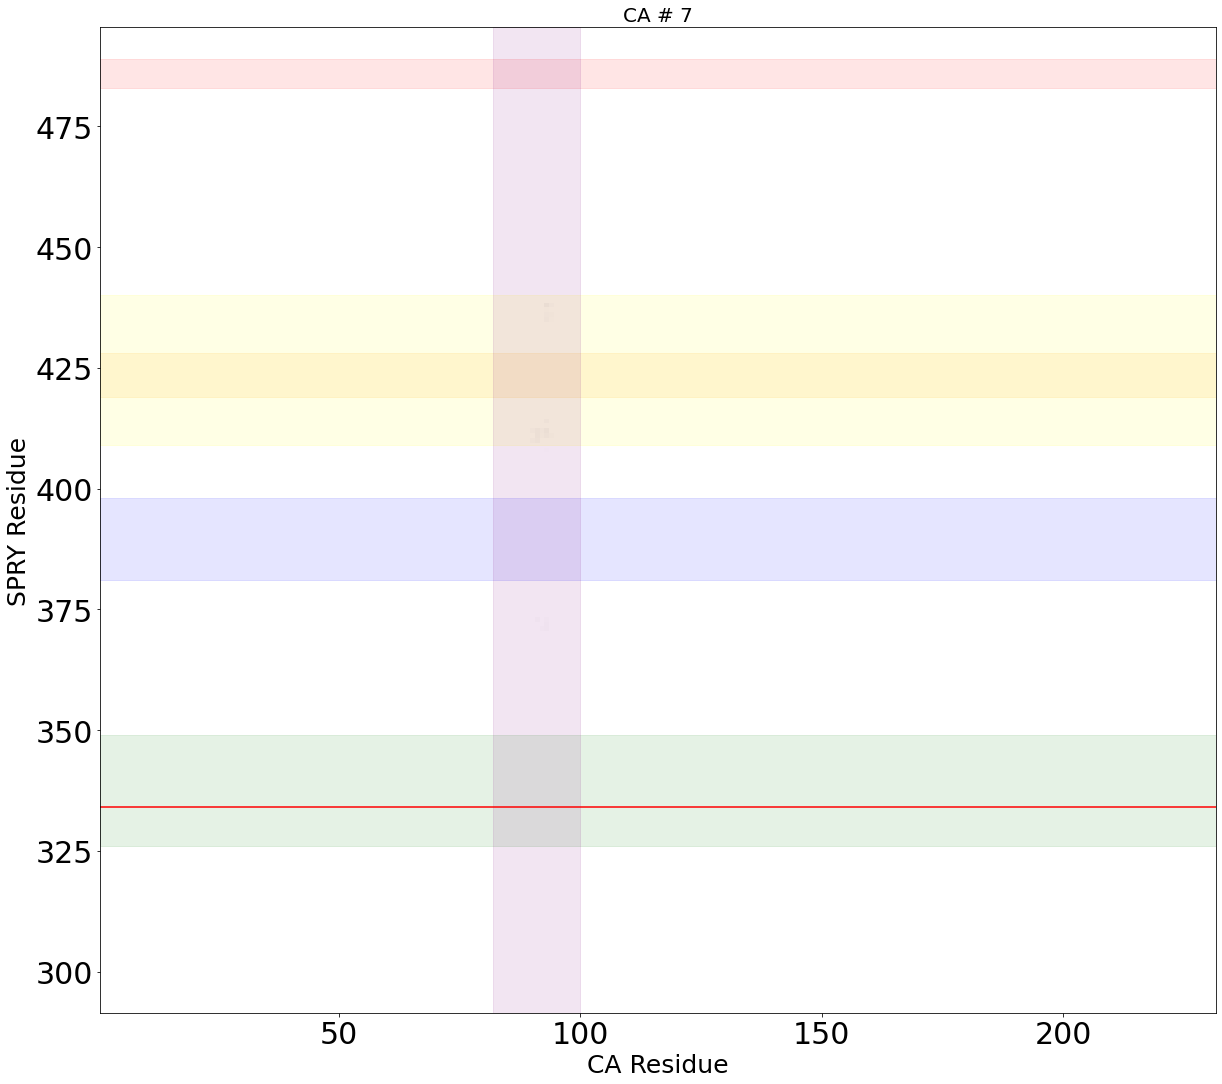

In [12]:
i=7
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1)
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")


axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

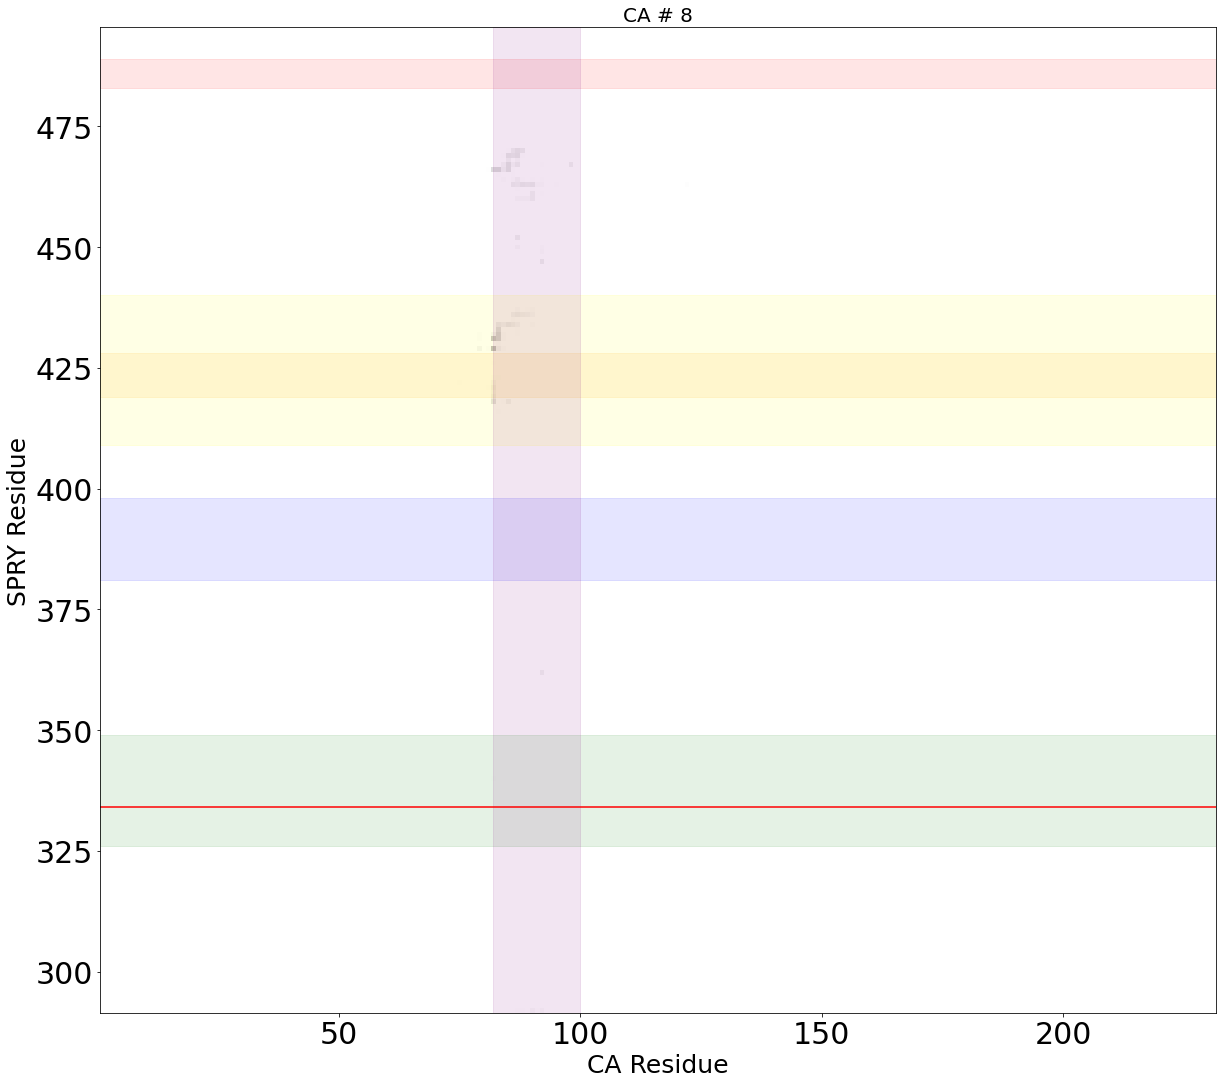

In [13]:
i=8
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1)
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

save("CA8_contacts.npy",contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))])

Text(0, 0.5, 'SPRY Residue')

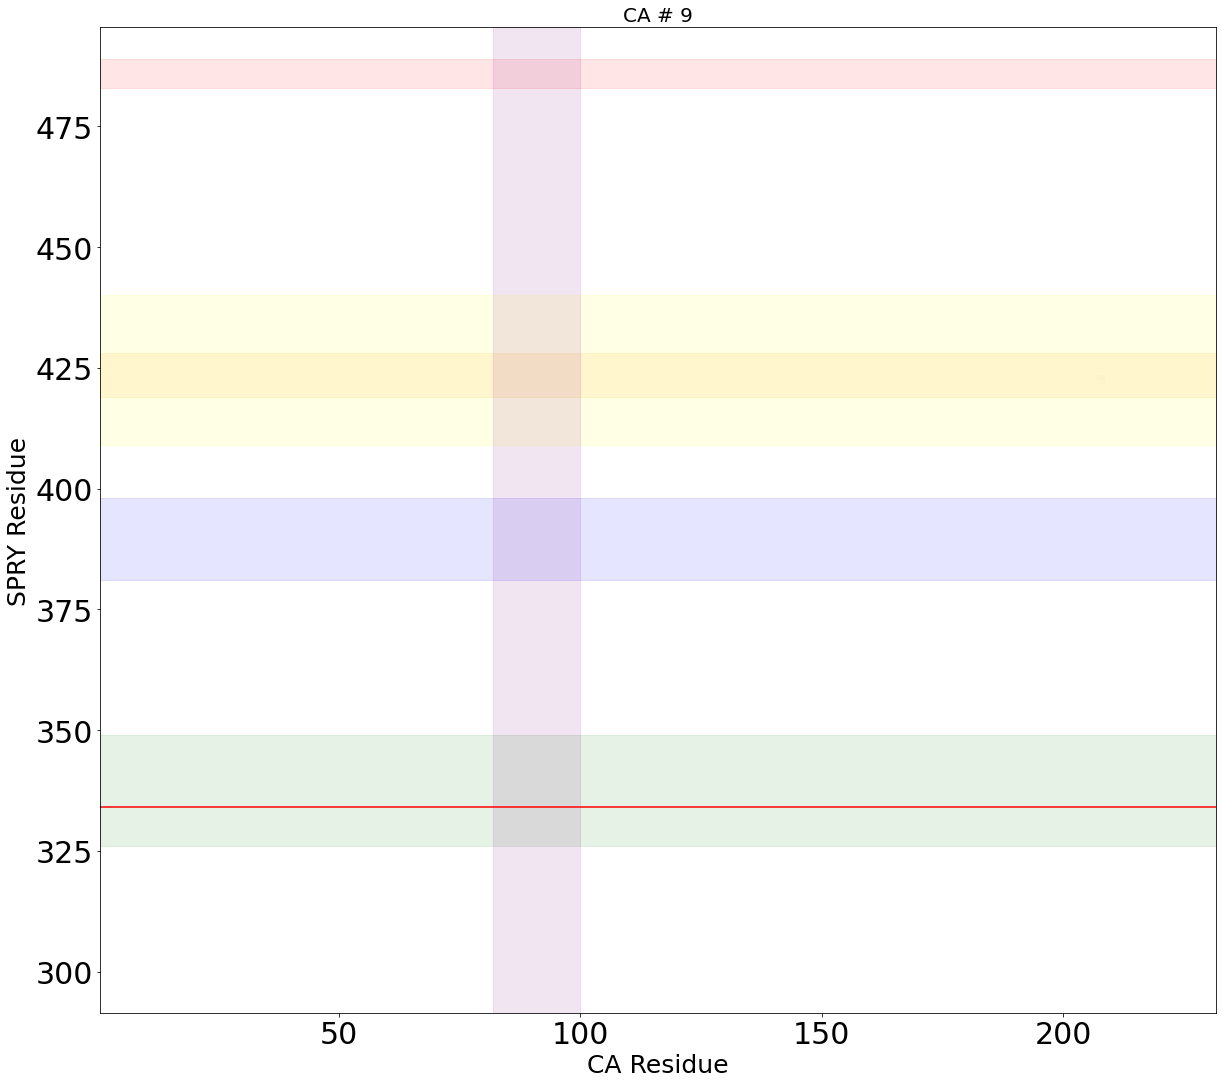

In [14]:
i=9
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1)
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

Text(0, 0.5, 'SPRY Residue')

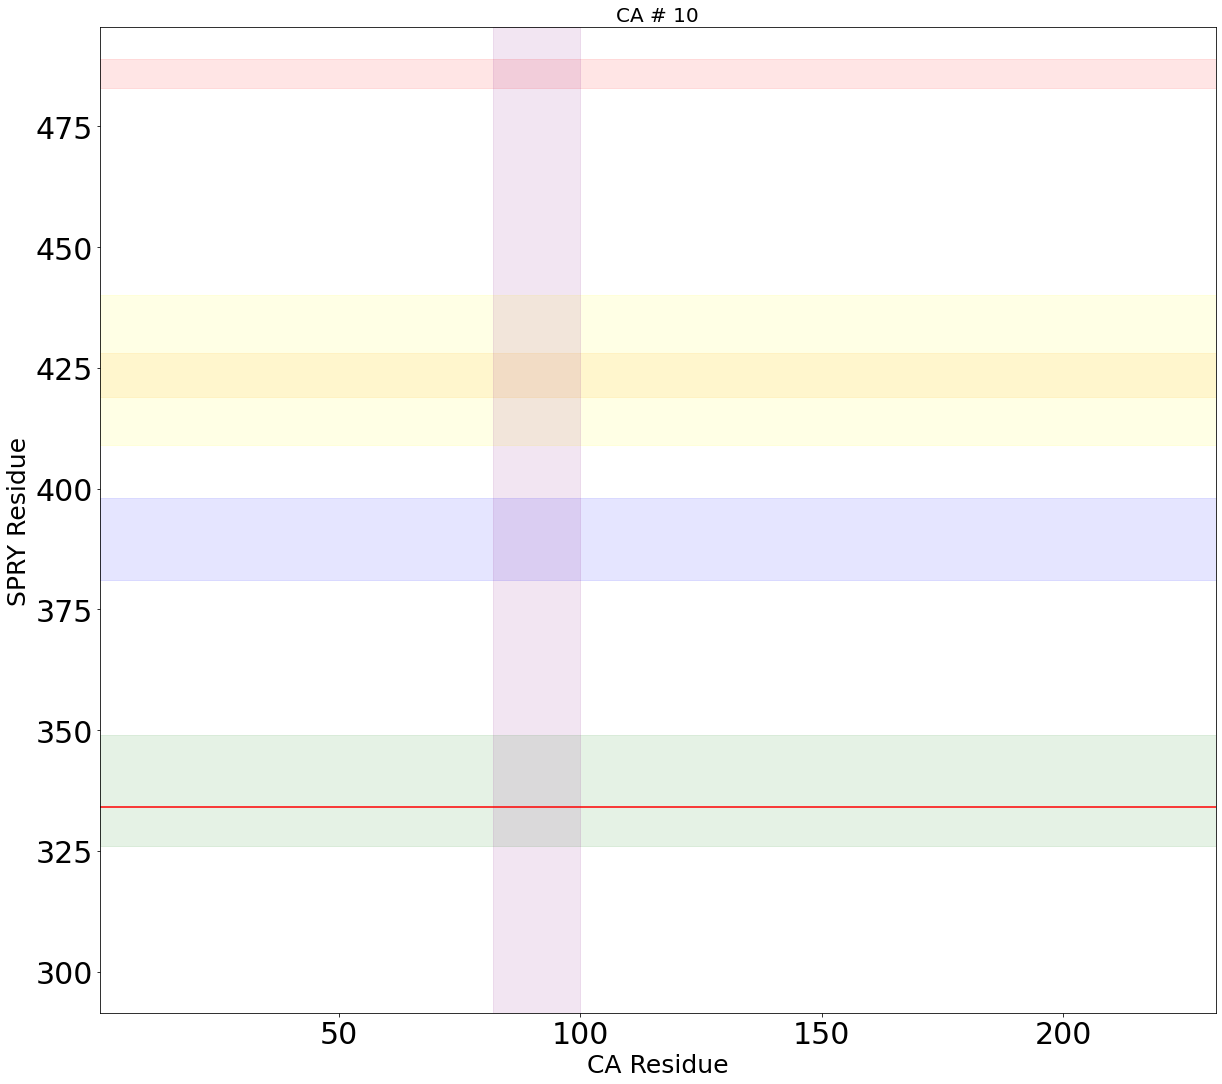

In [15]:
i=10
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

Text(0, 0.5, 'SPRY Residue')

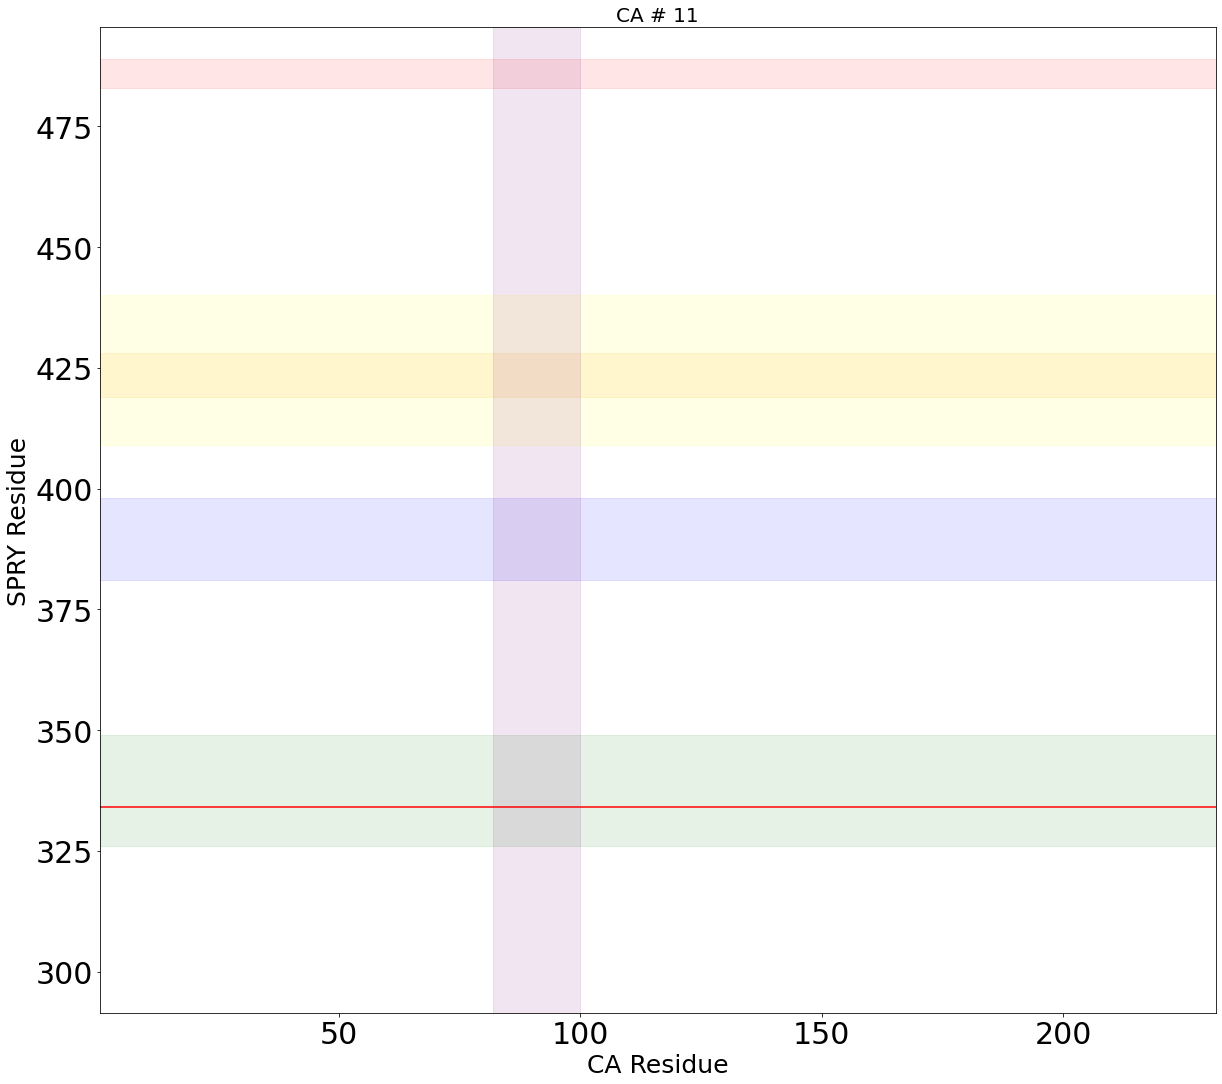

In [16]:
i=11
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1)
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

Text(0, 0.5, 'SPRY Residue')

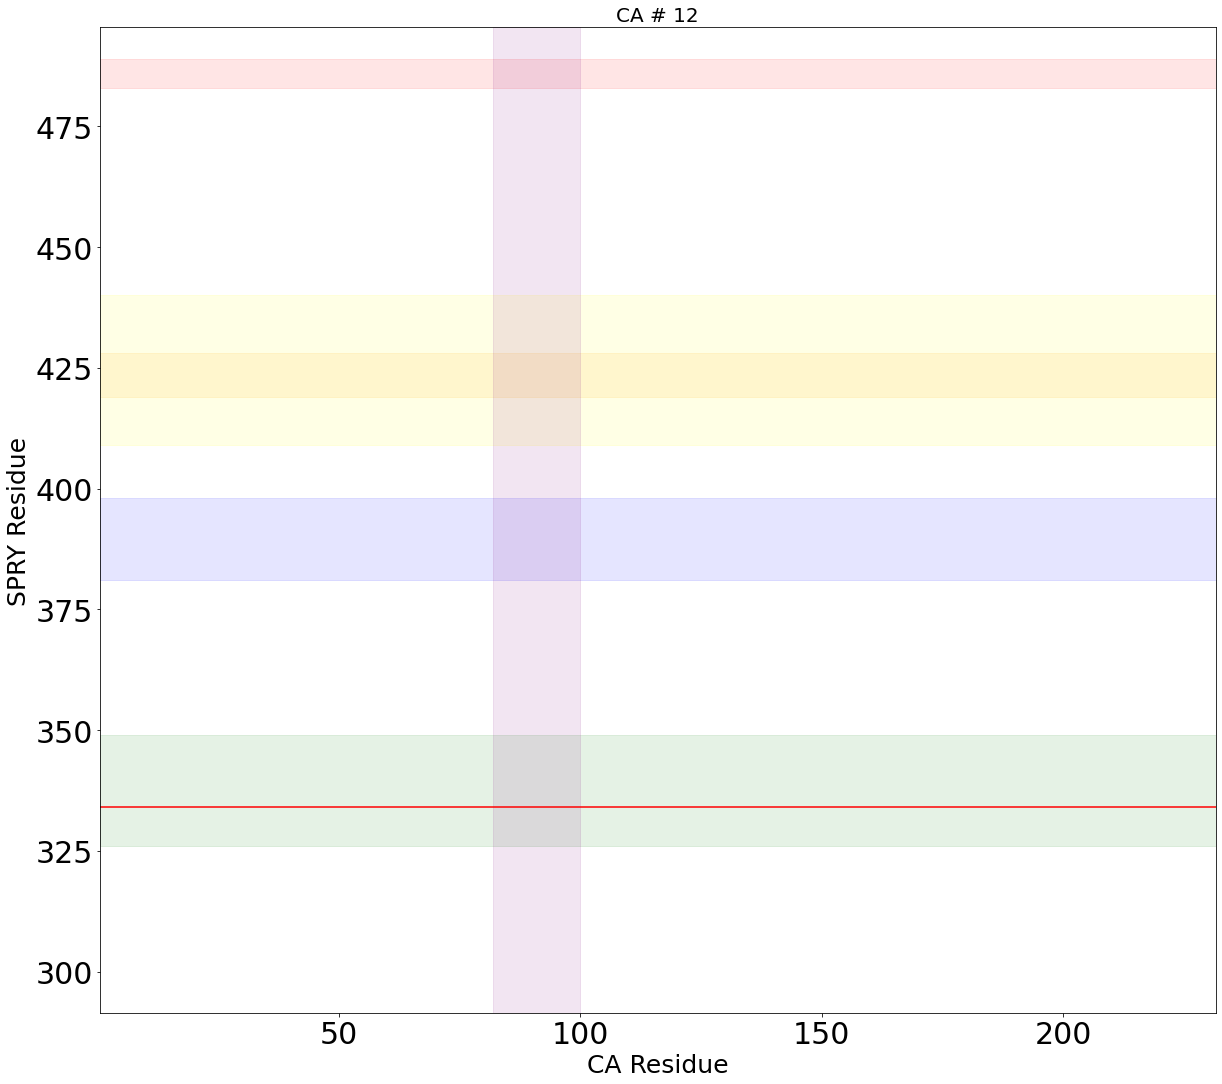

In [17]:
i=12
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

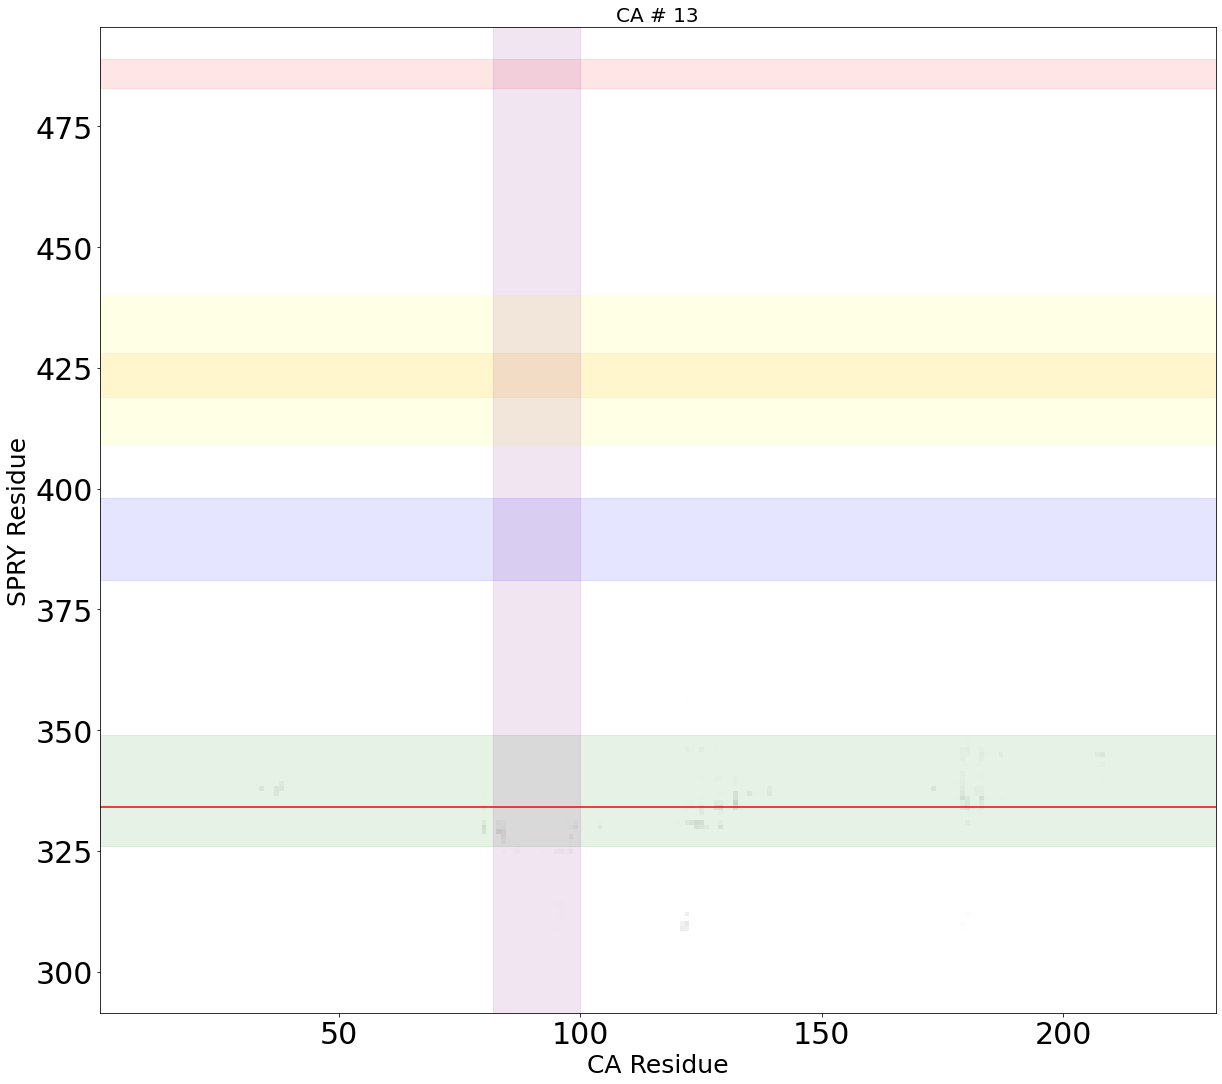

In [18]:
i=13
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)



axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

save("CA13_contacts.npy",contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))])

Text(0, 0.5, 'SPRY Residue')

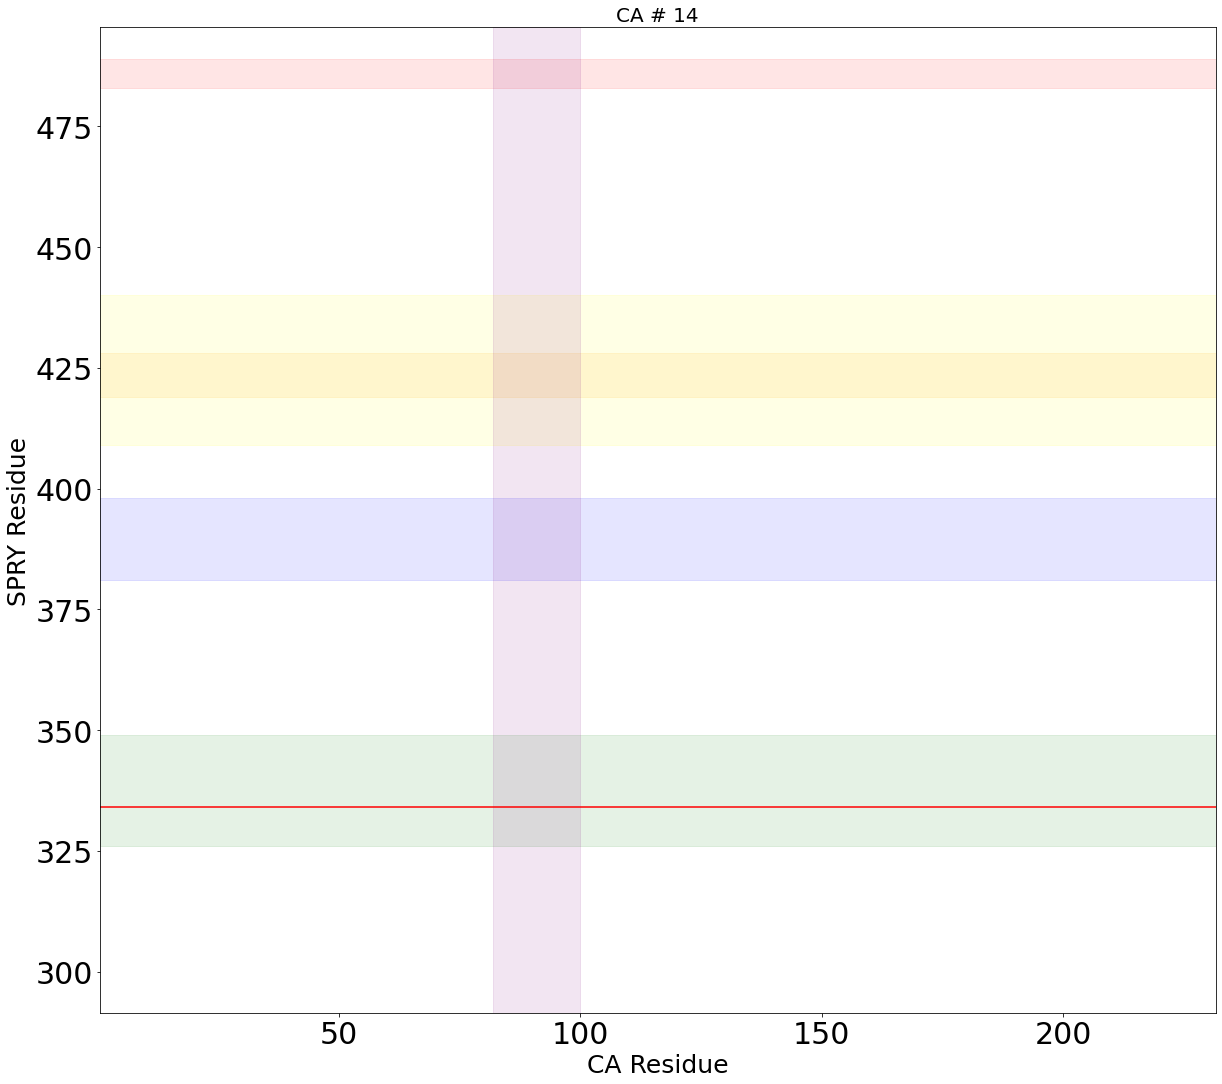

In [19]:
i=14
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)


axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

Text(0, 0.5, 'SPRY Residue')

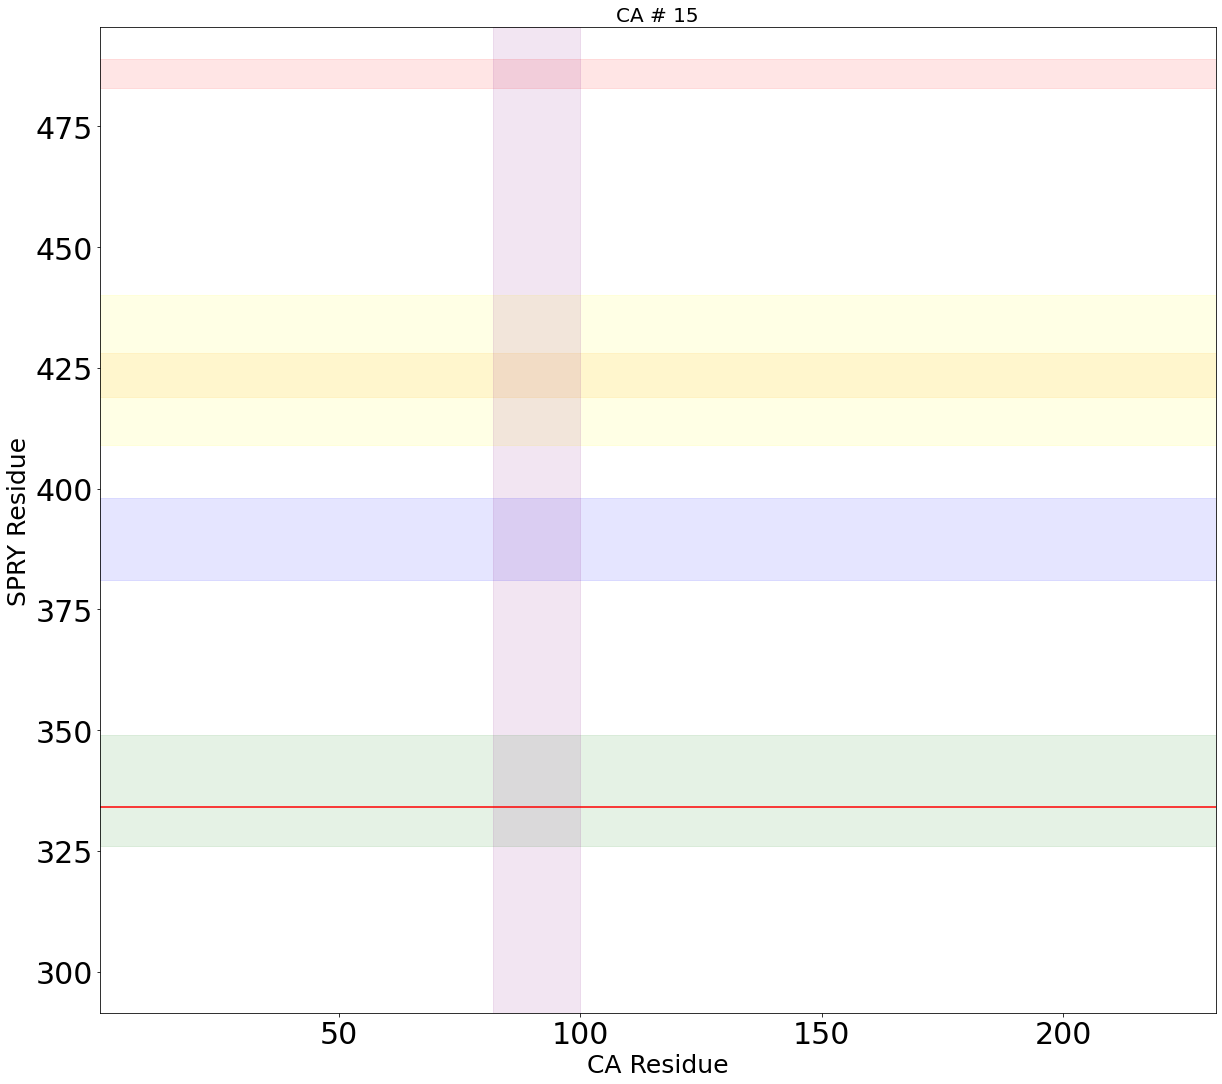

In [20]:
i=15
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)


axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

Text(0, 0.5, 'SPRY Residue')

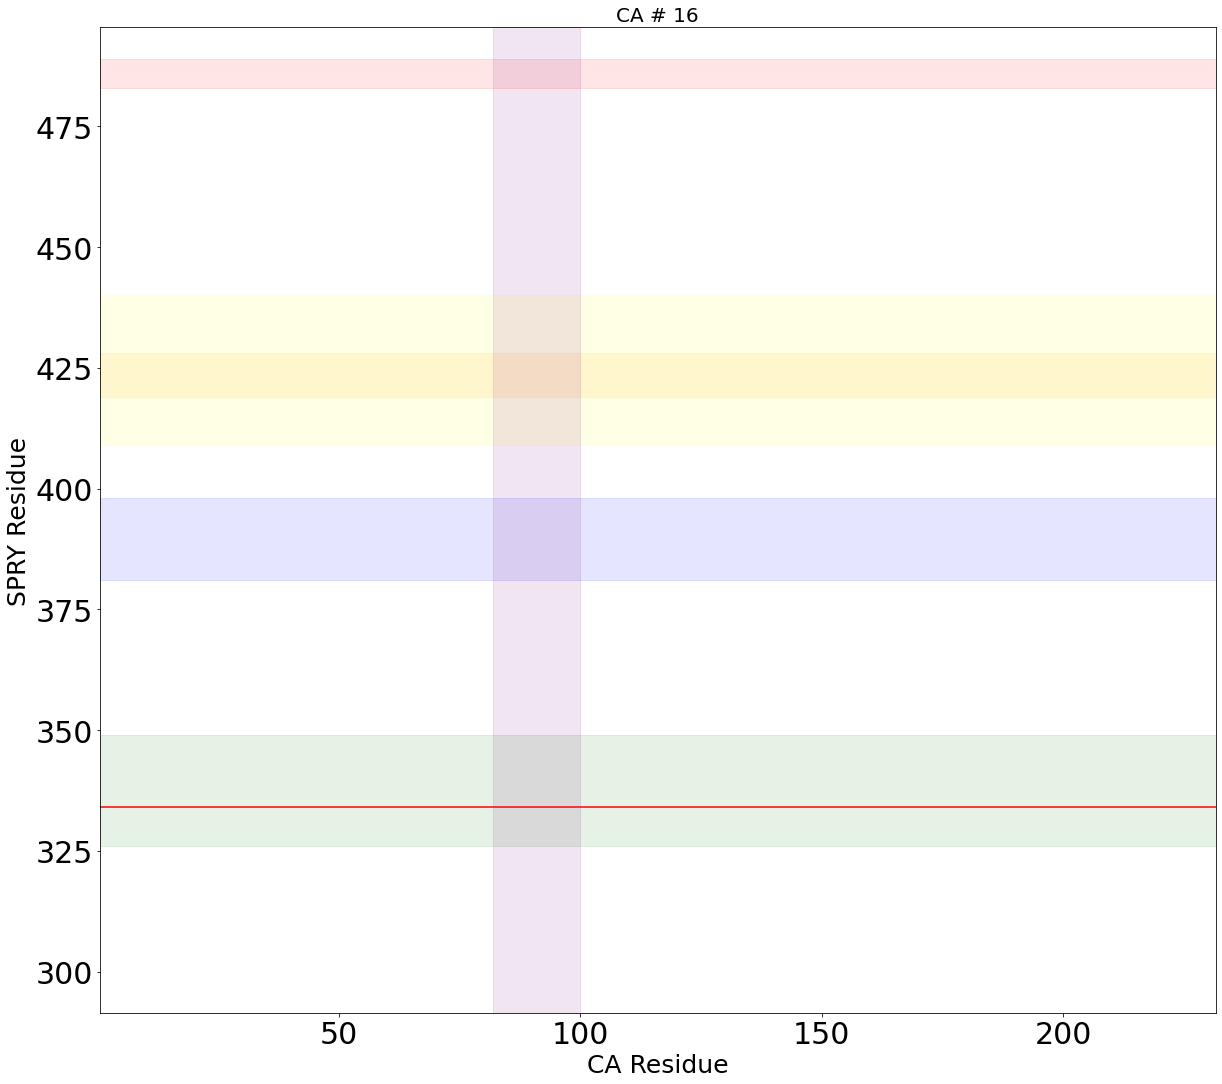

In [21]:
i=16
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1) 
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)


axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

Text(0, 0.5, 'SPRY Residue')

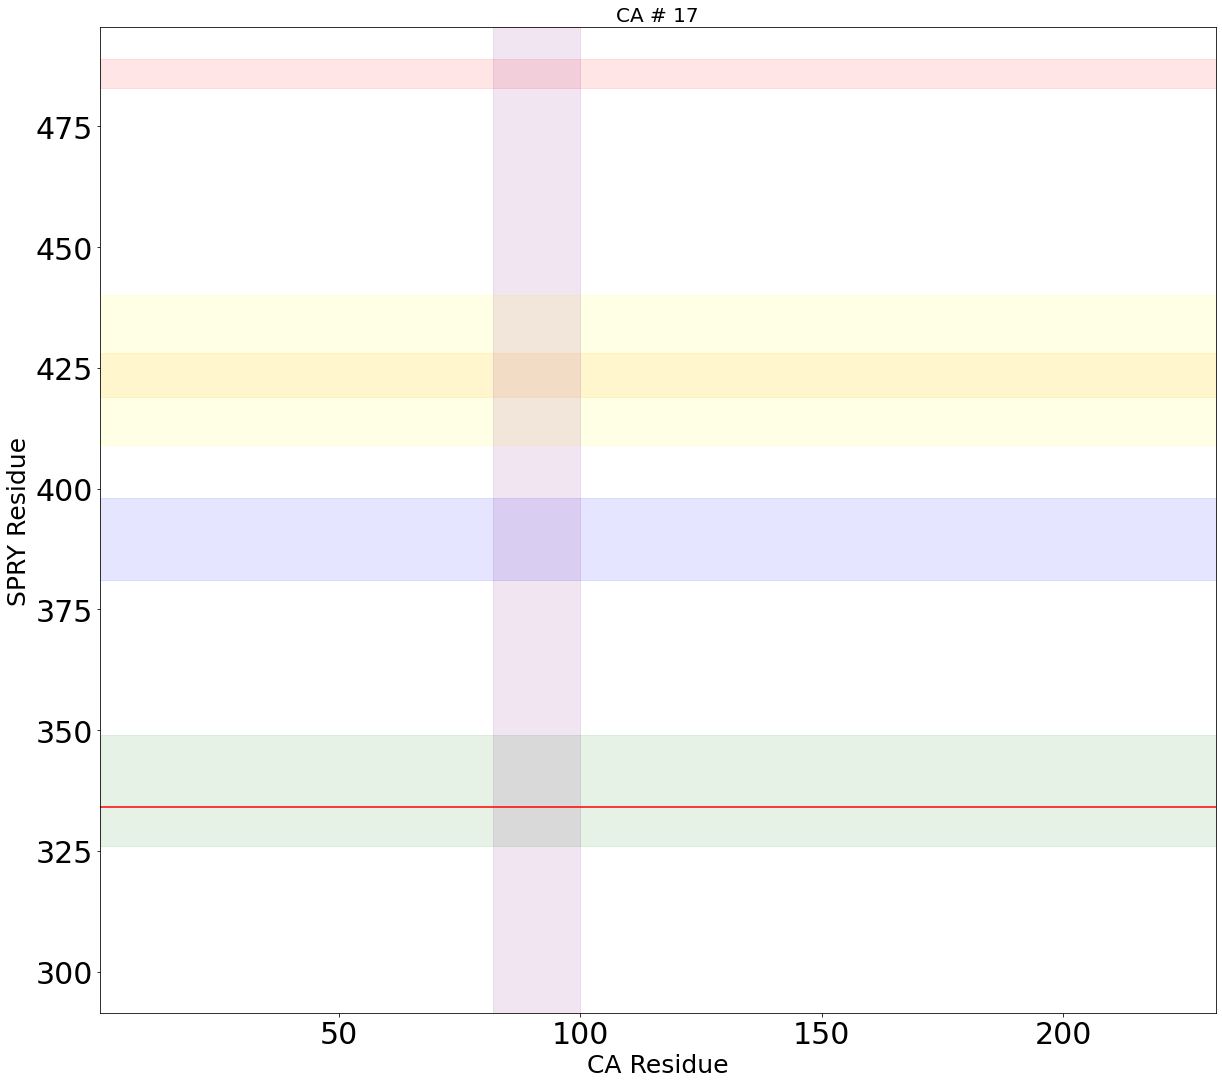

In [22]:
i=17
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1)
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)


axhline(334,color = "red")
axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

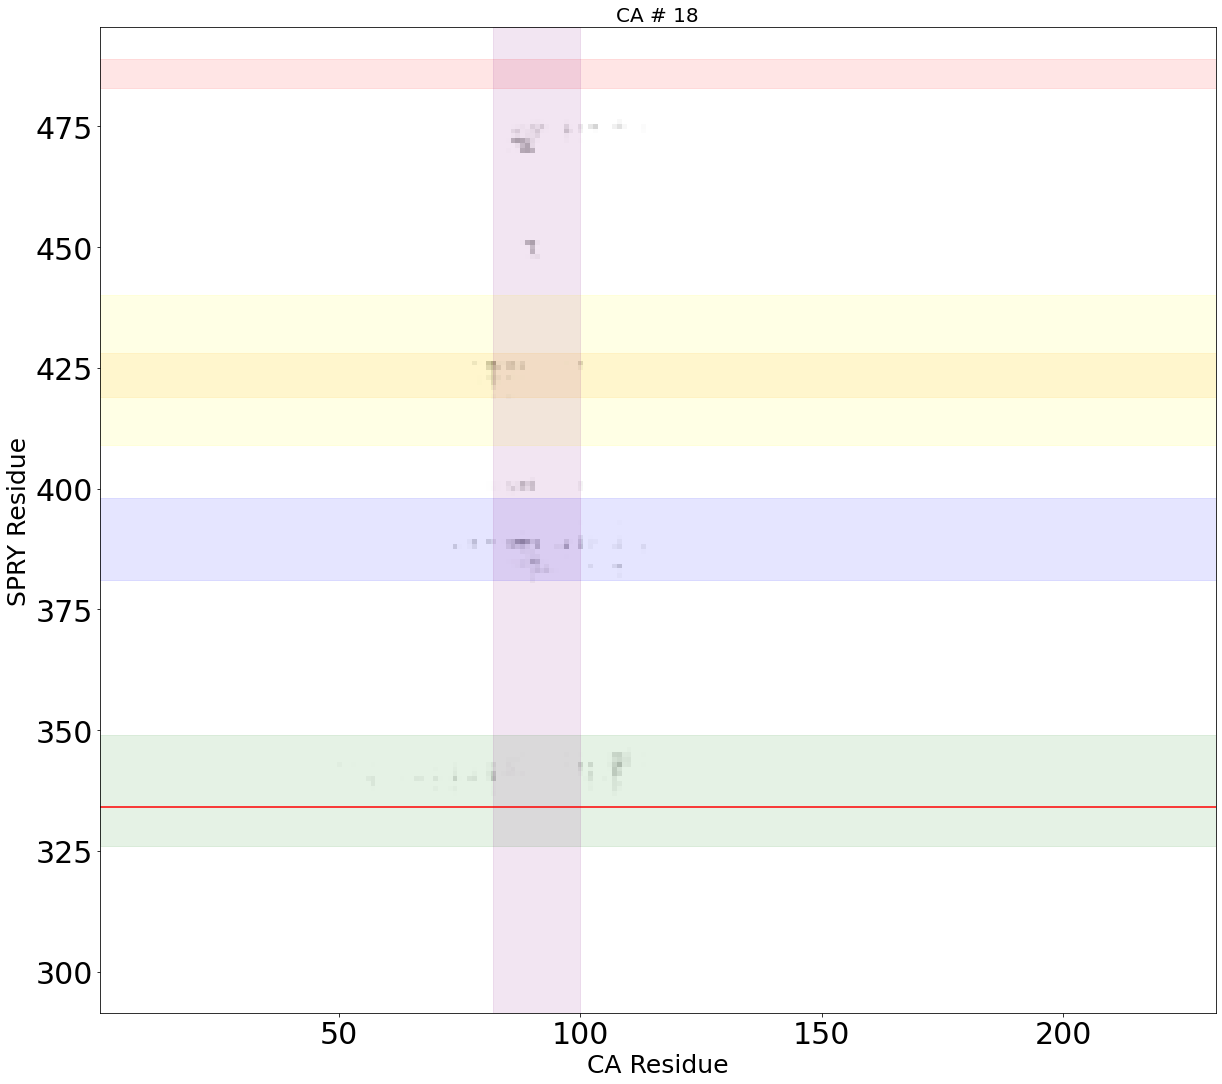

In [23]:


i=18
nspry = 493-290 + 1
figure(figsize = (20,20))
imshow(contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))],origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2),vmin = 0,vmax = 1)
title("CA # "+str(i),fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)


axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1)
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)


axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)
xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

save("CA18_contacts.npy",contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))])

In [24]:
contacts_2d.shape

(4362, 4362)

In [25]:
# There are 493 residues, and in THIS CASE, we are indexing from 0, so the SPRY domain should be given by 0:493-290 (since residue 493 is indexed at 492 (subtract off 290 since the 0th index is residue 290))
#spry = [:493-290]
# SPRY HAS 204 RESIDUES, IT NEED TO BE PLUS 1 U STUPID
# each capsid monomer is 231 residues, the FIRST capsid residue is the one that immediately follows the SPRY domain.
# IE, the index of the first capsid residue is 493-290. The last capsid residue is indexed at 
# 493 - 290
#capsid1 = [493-290: 493-290 + 231]
# subsequent capsid are index at 231 *i + the above
#capsidi = [493-290 + 231*(i-1), 493-290 + 231*i]





Text(0, 0.5, 'SPRY Residue')

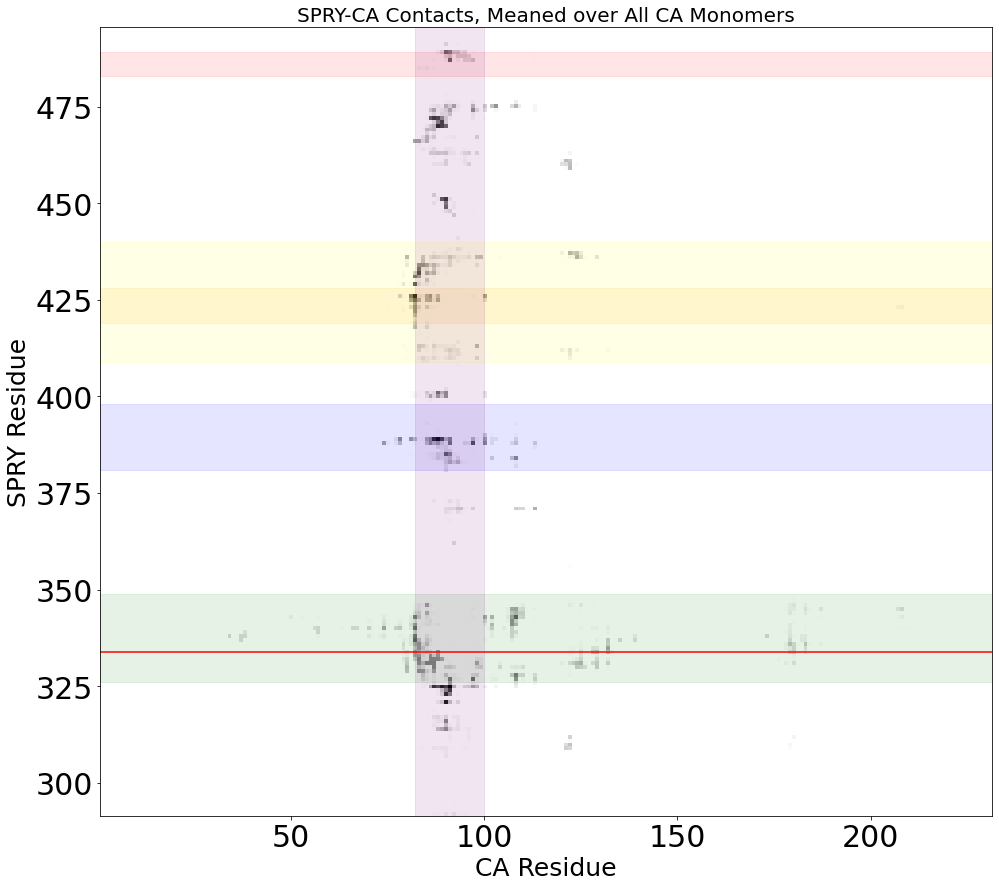

In [26]:
mean_over_cas_spry_contacts=0
for i in range(1,18+1):
    mean_over_cas_spry_contacts+=contacts_2d[:nspry,nspry+(231*(i-1)):nspry+(231*(i))]
mean_over_cas_spry_contacts/=18

figure(figsize = (16,16))

imshow(mean_over_cas_spry_contacts,origin = "lower",cmap = 'binary',extent = (.5,231.5,289.5 +2,493.5 +2))#,vmin = 0,vmax = 1)
title("SPRY-CA Contacts, Meaned over All CA Monomers",fontsize = 20)

xticks(fontsize = 30)
yticks(fontsize = 30)


axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1)
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)


axhline(334,color = "red")

axvspan(82,100,color = "purple",alpha = 0.1)


xlabel("CA Residue",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)

In [27]:
mean_over_cas_spry_contacts.shape

(204, 231)

(290.0, 495.0)

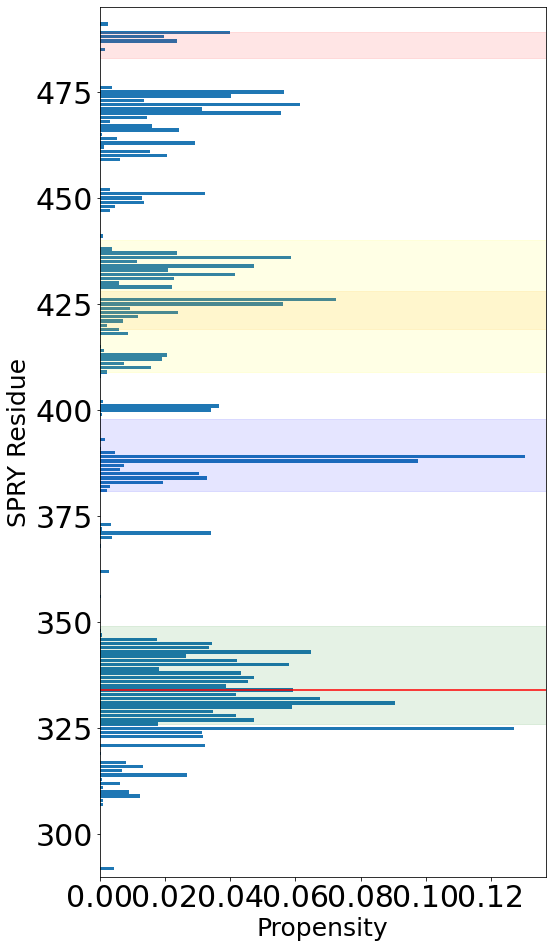

In [28]:
figure(figsize = (8,16))
barh(rhresids,sum(mean_over_cas_spry_contacts,axis=1))

axhspan(326,349,color = "green",alpha = 0.1)
axhspan(381,398,color = "blue",alpha = 0.1)
axhspan(419,428,color = "orange",alpha = 0.1)
axhspan(409,440,color = "yellow",alpha = 0.1)
axhspan(483,489,color = "red",alpha = 0.1)


axhline(334,color = "red")

xlabel("Propensity",fontsize = 25)
ylabel("SPRY Residue",fontsize = 25)
_=xticks(fontsize = 30)
_=yticks(fontsize = 30)
ylim(290,495)


#ylim(370,400)



In [29]:
for i in range(len(rhresids)):
    print(i,rhresids[i])

0 292
1 293
2 294
3 295
4 296
5 297
6 298
7 299
8 300
9 301
10 302
11 303
12 304
13 305
14 306
15 307
16 308
17 309
18 310
19 311
20 312
21 313
22 314
23 315
24 316
25 317
26 318
27 319
28 320
29 321
30 322
31 323
32 324
33 325
34 326
35 327
36 328
37 329
38 330
39 331
40 332
41 333
42 334
43 335
44 336
45 337
46 338
47 339
48 340
49 341
50 342
51 343
52 344
53 345
54 346
55 347
56 348
57 349
58 350
59 351
60 352
61 353
62 354
63 355
64 356
65 357
66 358
67 359
68 360
69 361
70 362
71 363
72 364
73 365
74 366
75 367
76 368
77 369
78 370
79 371
80 372
81 373
82 374
83 375
84 376
85 377
86 378
87 379
88 380
89 381
90 382
91 383
92 384
93 385
94 386
95 387
96 388
97 389
98 390
99 391
100 392
101 393
102 394
103 395
104 396
105 397
106 398
107 399
108 400
109 401
110 402
111 403
112 404
113 405
114 406
115 407
116 408
117 409
118 410
119 411
120 412
121 413
122 414
123 415
124 416
125 417
126 418
127 419
128 420
129 421
130 422
131 423
132 424
133 425
134 426
135 427
136 428
137 429
138 43

In [30]:
import pandas
df = pandas.DataFrame({"x": rhresids, "y": sum(mean_over_cas_spry_contacts,axis=1)})
print(df.to_string())

       x         y
0    292  0.004502
1    293  0.000000
2    294  0.000133
3    295  0.000200
4    296  0.000000
5    297  0.000000
6    298  0.000000
7    299  0.000000
8    300  0.000000
9    301  0.000000
10   302  0.000000
11   303  0.000000
12   304  0.000000
13   305  0.000000
14   306  0.000000
15   307  0.001109
16   308  0.001087
17   309  0.012486
18   310  0.008982
19   311  0.000954
20   312  0.006343
21   313  0.000732
22   314  0.026813
23   315  0.006942
24   316  0.013262
25   317  0.008228
26   318  0.000133
27   319  0.000399
28   320  0.000111
29   321  0.032380
30   322  0.000067
31   323  0.031737
32   324  0.031448
33   325  0.127190
34   326  0.017898
35   327  0.047416
36   328  0.041783
37   329  0.034753
38   330  0.059126
39   331  0.090685
40   332  0.067598
41   333  0.041694
42   334  0.059304
43   335  0.038767
44   336  0.045576
45   337  0.047217
46   338  0.043247
47   339  0.018252
48   340  0.057973
49   341  0.042071
50   342  0.026613
51   343  0.

(81.0, 102.0)

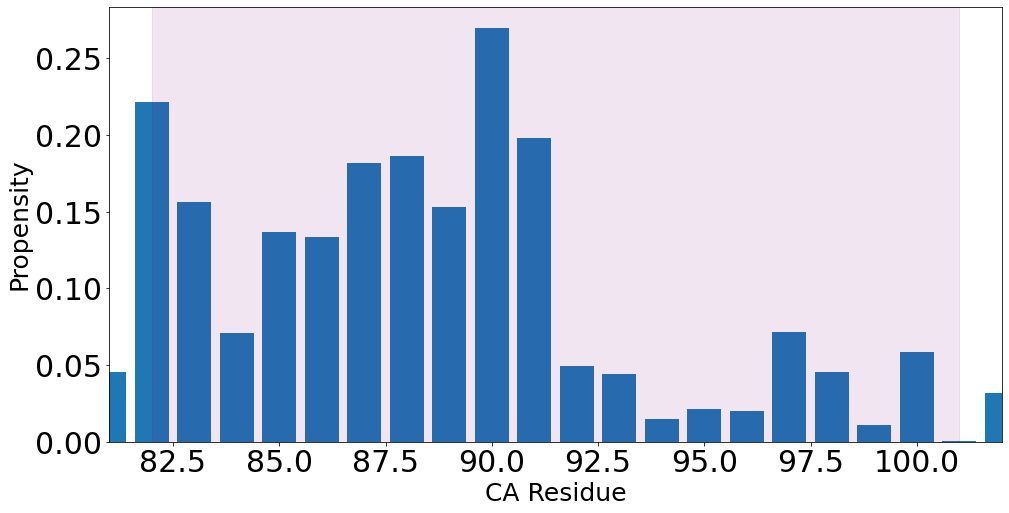

In [31]:
figure(figsize = (16,8))
bar(arange(1,232),sum(mean_over_cas_spry_contacts,axis=0))
#axhspan(326,349,color = "green",alpha = 0.1)
#axhspan(381,398,color = "blue",alpha = 0.1)
#axhspan(419,428,color = "orange",alpha = 0.1) axhspan(409,440,color = "yellow",alpha = 0.1)
#axhspan(483,489,color = "red",alpha = 0.1)
ylabel("Propensity",fontsize = 25)
xlabel("CA Residue",fontsize = 25)
_=xticks(fontsize = 30)
_=yticks(fontsize = 30)
#ylim(290,493)
axvspan(82,101,color = "purple",alpha = 0.1)

xlim(81,102)